Всего кофеен: 758
Колонки: ['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']
\Основные метрики
Средний рейтинг: 4.307915567282321
Доля сетевых кофеен: 0.4788918205804749
Уровни цен: price
средние          377
низкие            68
высокие           17
выше среднего     14
Name: count, dtype: int64
\Сетевые / независимые
Средний рейтинг сетевых: 4.22
Средний рейтинг независимых: 4.39
p-value: 0.0000 -> разница значима
\Центр and другие округа
Средний рейтинг в центре: nan
Средний рейтинг вне центра: 4.31
p-value: nan -> разница не значима
\Распределение цен по округам
price                                    высокие  выше среднего  низкие  \
district                                                                  
Восточный административный округ             0.0            1.0    10.0   
Западный административный округ              1.0            3.0     4.0   
Северный административный окр

/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


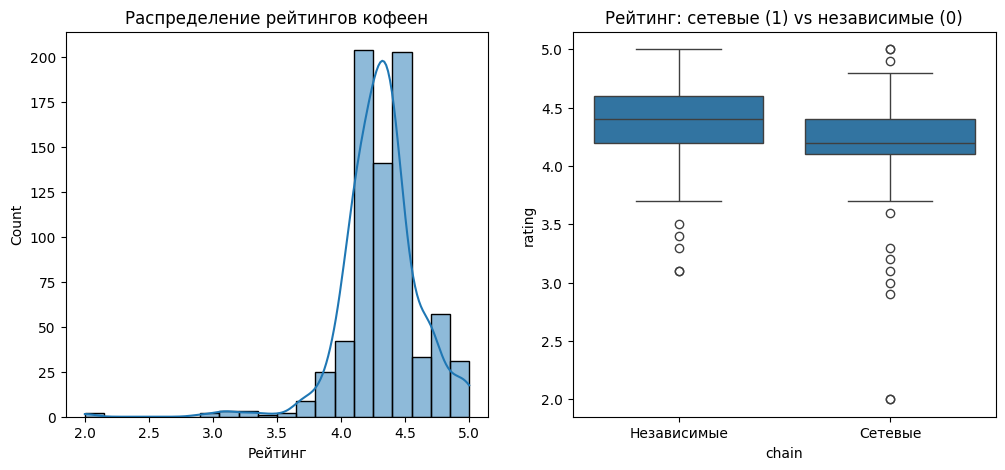

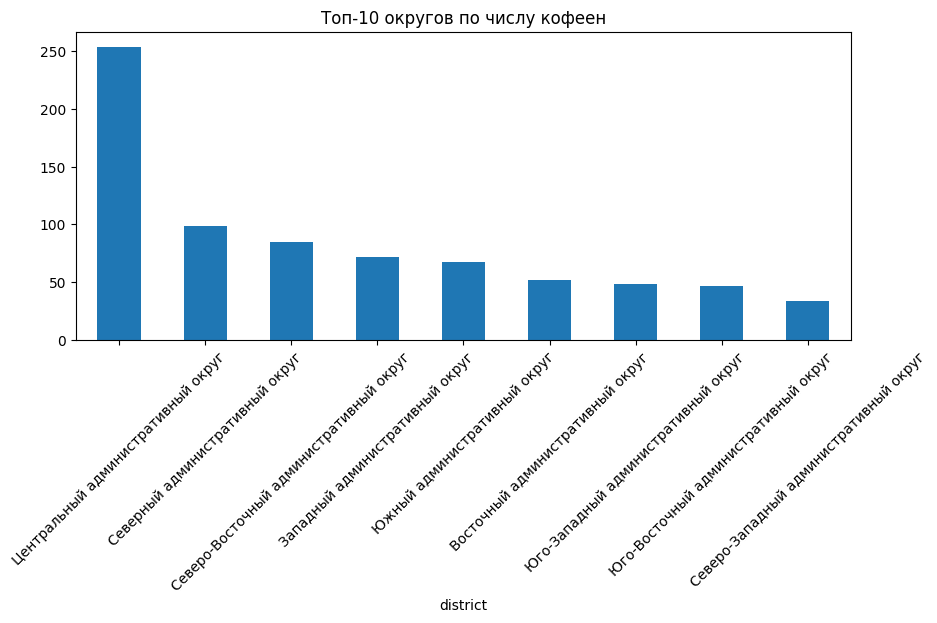

\Примеры кофеен с низким рейтингом (потенциальные слабые места конкурентов)
                  name                                   address  rating  \
717           КОФЕПОРТ  Москва, 3-я Хорошёвская улица, 2, стр. 1     2.0   
3230             Cofix         Москва, улица Орджоникидзе, 11с1А     2.0   
3026      Coffee Music               Москва, Можайское шоссе, 21     2.9   
280          Coffprice            Москва, Фестивальная улица, 2Б     3.0   
1198  One Price Coffee     Москва, Сокольническая площадь, 4к1-2     3.1   

                                    district  
717   Северо-Западный административный округ  
3230            Южный административный округ  
3026         Западный административный округ  
280          Северный административный округ  
1198        Восточный административный округ  
\Примеры кофеен с высоким рейтингом
                          name                                      address  \
2         Dormouse Coffee Shop          Москва, улица Маршала Федоренк

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
from io import StringIO

info_url = 'https://code.s3.yandex.net/datasets/rest_info.csv'
price_url = 'https://code.s3.yandex.net/datasets/rest_price.csv'
rest_info = pd.read_csv(info_url)
rest_price = pd.read_csv(price_url)
df = rest_info.merge(rest_price, on='id')
df = df[df['category'] == 'кофейня'].copy()

print("Всего кофеен:", len(df))
print("Колонки:", df.columns.tolist())

df['is_center'] = df['district'] == 'Центральный'

print("\Основные метрики")
print("Средний рейтинг:", df['rating'].mean())
print("Доля сетевых кофеен:", df['chain'].mean())
print("Уровни цен:", df['price'].value_counts())

chain_ratings = df[df['chain'] == 1]['rating'].dropna()
indie_ratings = df[df['chain'] == 0]['rating'].dropna()
t_stat, p_val = stats.ttest_ind(chain_ratings, indie_ratings)
print(f"\Сетевые / независимые")
print(f"Средний рейтинг сетевых: {chain_ratings.mean():.2f}")
print(f"Средний рейтинг независимых: {indie_ratings.mean():.2f}")
print(f"p-value: {p_val:.4f} -> {'разница значима' if p_val < 0.05 else 'разница не особо значима'}")

# посмотрим центр или не центр (по рейтингу)
center_ratings = df[df['is_center'] == True]['rating'].dropna()
noncenter_ratings = df[df['is_center'] == False]['rating'].dropna()
t_stat2, p_val2 = stats.ttest_ind(center_ratings, noncenter_ratings)
print(f"\Центр and другие округа")
print(f"Средний рейтинг в центре: {center_ratings.mean():.2f}")
print(f"Средний рейтинг вне центра: {noncenter_ratings.mean():.2f}")
print(f"p-value: {p_val2:.4f} -> {'разница значима' if p_val2 < 0.05 else 'разница не значима'}")

# анализ цен по районам
price_by_district = df.groupby('district')['price'].value_counts().unstack().fillna(0)
print("\Распределение цен по округам")
print(price_by_district)

# графики
plt.figure(figsize=(12, 5))

# гистограмма рейтингов
plt.subplot(1, 2, 1)
sns.histplot(df['rating'].dropna(), bins=20, kde=True)
plt.title('Распределение рейтингов кофеен')
plt.xlabel('Рейтинг')

# boxplot рейтингов по типу (сетевые/нет)
plt.subplot(1, 2, 2)
sns.boxplot(x='chain', y='rating', data=df)
plt.title('Рейтинг: сетевые (1) vs независимые (0)')
plt.xticks([0,1], ['Независимые', 'Сетевые'])
plt.show()

# топ-10 районов по количеству кофеен
top_districts = df['district'].value_counts().head(10)
plt.figure(figsize=(10,4))
top_districts.plot(kind='bar')
plt.title('Топ-10 округов по числу кофеен')
plt.xticks(rotation=45)
plt.show()

# карта
print("\Примеры кофеен с низким рейтингом (потенциальные слабые места конкурентов)")
print(df.nsmallest(5, 'rating')[['name', 'address', 'rating', 'district']])

print("\Примеры кофеен с высоким рейтингом")
print(df.nlargest(5, 'rating')[['name', 'address', 'rating', 'district']])